In [10]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, silhouette_score
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# MiniLearn — your from-scratch library
# from minilearn.classifiers import LogisticRegression, KNN, GaussianNaiveBayes, DecisionTreeClassifier
# from minilearn.preprocessing import StandardScaler, train_test_split
# from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])

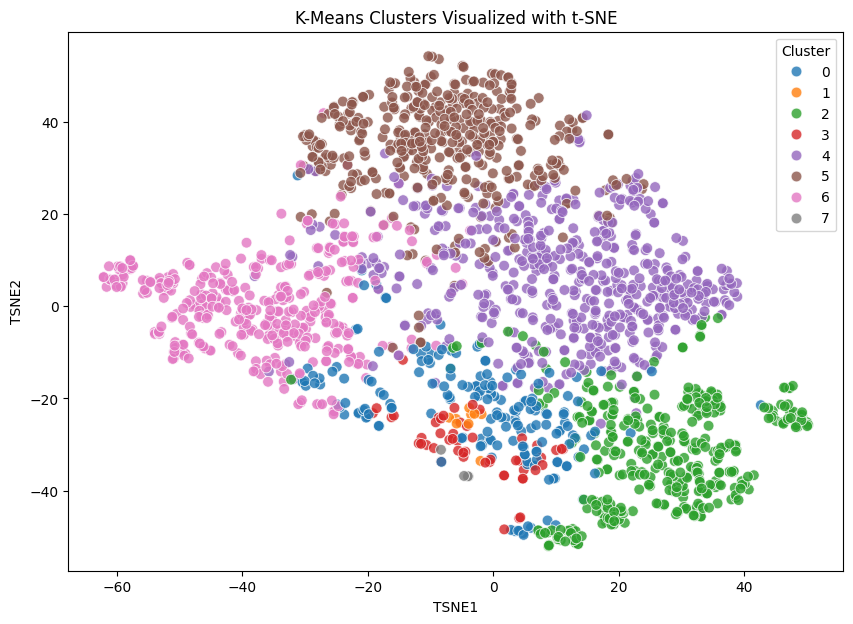

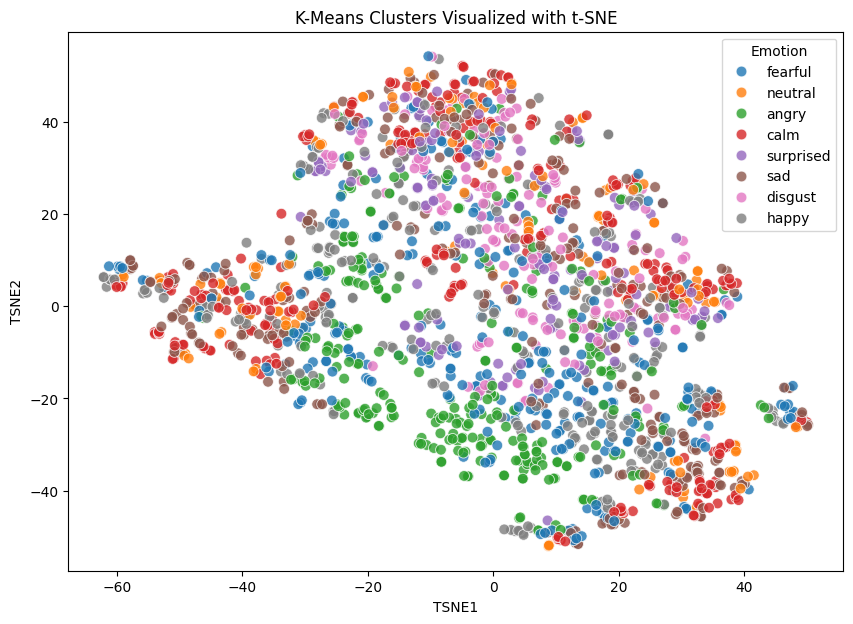

In [8]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

cluster = KMeans(n_clusters=8, random_state=42)
labels = cluster.fit_predict(X_train_scaled)

plotable = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled)


plot_df = pd.DataFrame({"TSNE1": plotable[:, 0], "TSNE2": plotable[:, 1], "Cluster": labels, "Emotion": y_train.values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Emotion", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

In [16]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

scores = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_train_scaled)

    score = silhouette_score(X_train_scaled, labels)
    scores.append(score)

    print(k, score)

2 0.6707724642205796
3 0.5154698461676163
4 0.09227536376937225
5 0.07916341274786709
6 0.07870528690738615
7 0.07906266304388457
8 0.06275117340691722
9 0.06305539921852779
10 0.06261853673048819
11 0.06415421946357654
12 0.06375507677207602
13 0.06333520111176755
14 0.06384443341742471
15 0.06250252197714194
16 0.05836120148800109
17 0.05682835005095899
18 0.05701725588468749
19 0.05551281688383189


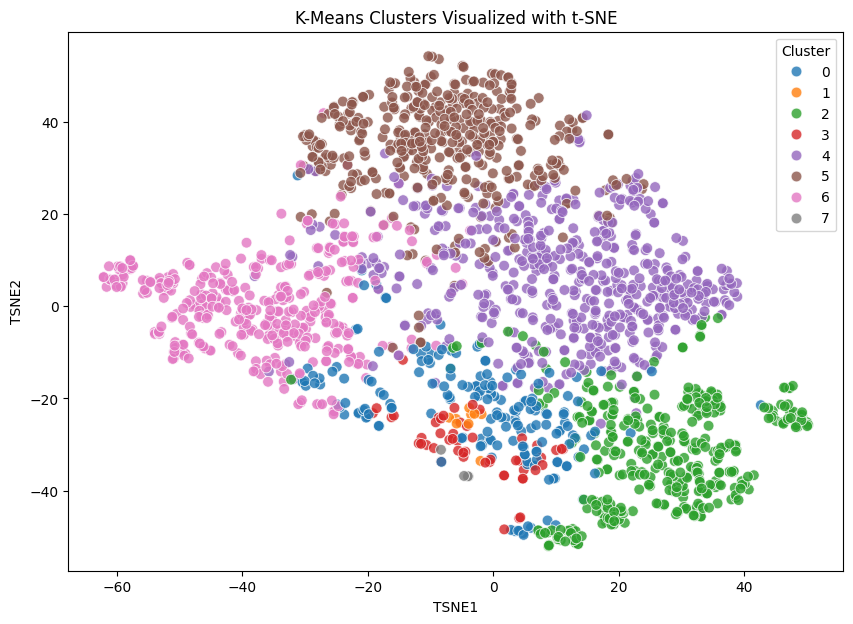

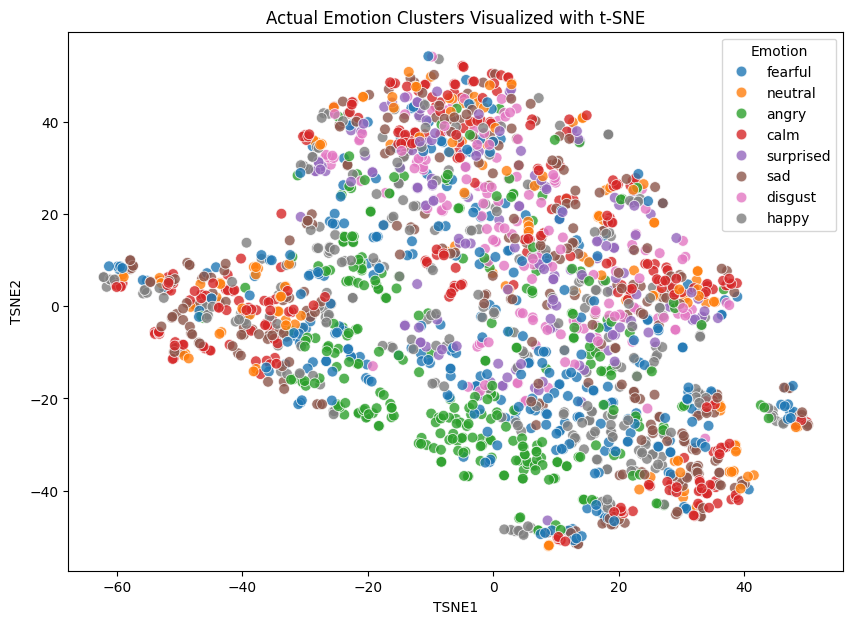

In [19]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

cluster = KMeans(n_clusters=8, random_state=42)
labels = cluster.fit_predict(X_train_scaled)

plotable = TSNE(n_components=2, random_state=42).fit_transform(X_train_scaled)


plot_df = pd.DataFrame({"TSNE1": plotable[:, 0], "TSNE2": plotable[:, 1], "Cluster": labels, "Emotion": y_train.values})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Cluster", palette="tab10", s=60, alpha=0.8)
plt.title("K-Means Clusters Visualized with t-SNE")
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="TSNE1", y="TSNE2", hue="Emotion", palette="tab10", s=60, alpha=0.8)
plt.title("Actual Emotion Clusters Visualized with t-SNE")
plt.show()